In [12]:
# Step 01: Generating Ensemble Predictions

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the predictions we just saved
df_prophet = pd.read_csv('../data/processed/prophet_preds.csv', parse_dates=['date'])
df_xgb = pd.read_csv('../data/processed/xgb_preds.csv', parse_dates=['date'])

# 2. Merge them together so everything aligns perfectly by date
df_ensemble = pd.merge(df_prophet, df_xgb, on='date')

# 3. Create the Weighted Ensemble! 
# We give XGBoost slightly more weight because it usually performs better on this dataset
w_prophet = 0.40
w_xgb = 0.60

df_ensemble['ensemble_pred'] = (df_ensemble['prophet_pred'] * w_prophet) + (df_ensemble['xgb_pred'] * w_xgb)

# 4. Create the Naive Baseline (predicting exactly what happened 365 days ago)
# Since we are predicting the last 92 days of the dataset, we just shift the actuals by 92 for a simple baseline
df_ensemble['naive_baseline'] = df_ensemble['actual_sales'].shift(92).fillna(df_ensemble['actual_sales'].mean())

print("Ensemble predictions generated successfully!")
print(df_ensemble.head())

Ensemble predictions generated successfully!
        date  actual_sales  prophet_pred   xgb_pred  ensemble_pred  \
0 2017-10-01            21     26.671029  26.863739      26.786655   
1 2017-10-02            12     18.621239  16.864351      17.567106   
2 2017-10-03            18     21.191686  20.287334      20.649075   
3 2017-10-04            15     21.917413  20.394491      21.003660   
4 2017-10-05            20     22.506949  21.588192      21.955695   

   naive_baseline  
0       20.228261  
1       20.228261  
2       20.228261  
3       20.228261  
4       20.228261  


In [14]:
# Step 02: Visualization

FINAL SCORES:
         Model      MAE     RMSE  MAPE (%)
naive_baseline 4.634452 5.823683 28.698522
  prophet_pred 3.794949 4.579386 23.487460
      xgb_pred 3.917895 4.725629 23.490304
 ensemble_pred 3.811182 4.593242 23.194857


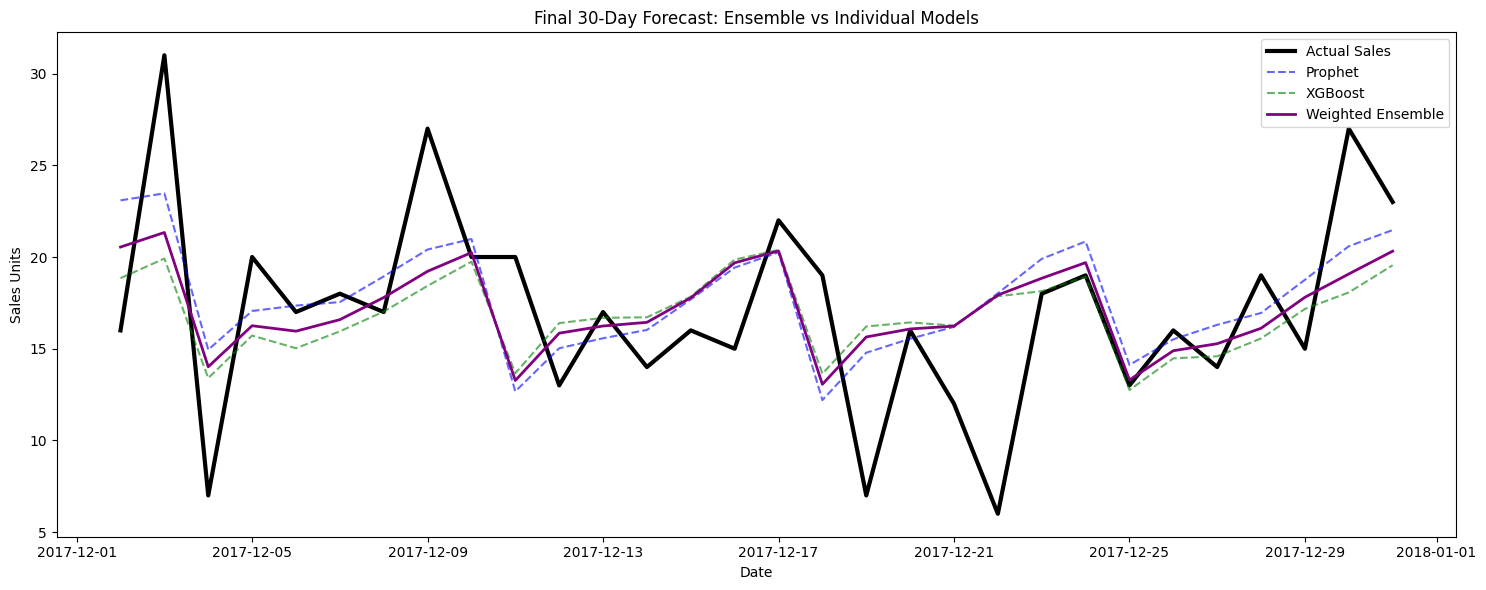

In [16]:
# Helper function for MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

models = ['naive_baseline', 'prophet_pred', 'xgb_pred', 'ensemble_pred']
results = []

for model in models:
    mae = mean_absolute_error(df_ensemble['actual_sales'], df_ensemble[model])
    rmse = np.sqrt(mean_squared_error(df_ensemble['actual_sales'], df_ensemble[model]))
    mape = calculate_mape(df_ensemble['actual_sales'], df_ensemble[model])
    
    results.append({'Model': model, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})

results_df = pd.DataFrame(results)
print("FINAL SCORES:")
print(results_df.to_string(index=False))

# Visualizing the final 30 days instead of 90 days so the chart isn't too crowded
plot_df = df_ensemble.tail(30)

plt.figure(figsize=(15, 6))
plt.plot(plot_df['date'], plot_df['actual_sales'], label='Actual Sales', color='black', linewidth=3)
plt.plot(plot_df['date'], plot_df['prophet_pred'], label='Prophet', linestyle='--', color='blue', alpha=0.6)
plt.plot(plot_df['date'], plot_df['xgb_pred'], label='XGBoost', linestyle='--', color='green', alpha=0.6)
plt.plot(plot_df['date'], plot_df['ensemble_pred'], label='Weighted Ensemble', color='purple', linewidth=2)

plt.title('Final 30-Day Forecast: Ensemble vs Individual Models')
plt.xlabel('Date')
plt.ylabel('Sales Units')
plt.legend()
plt.tight_layout()
plt.savefig('../results/final_30_days_forecast.png', dpi=150)
plt.show()